In [2]:
import os
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 解决负号'-'显示为方块的问题

In [3]:
df=pd.read_csv('D:/DAproject/电商数据分析/电子产品销售分析.csv')
df.head(10)

,Unnamed: 0,event_time,order_id,product_id,category_id,category_code,brand,price,user_id,age,sex,local
0,0,2020-04-24 11:50:39 UTC,2294359932054536986,1515966223509089906,2.268105e+18,electronics.tablet,samsung,162.01,1.515916e+18,24.0,女,海南
1,1,2020-04-24 11:50:39 UTC,2294359932054536986,1515966223509089906,2.268105e+18,electronics.tablet,samsung,162.01,1.515916e+18,24.0,女,海南
2,2,2020-04-24 14:37:43 UTC,2294444024058086220,2273948319057183658,2.268105e+18,electronics.audio.headphone,huawei,77.52,1.515916e+18,38.0,女,北京
3,3,2020-04-24 14:37:43 UTC,2294444024058086220,2273948319057183658,2.268105e+18,electronics.audio.headphone,huawei,77.52,1.515916e+18,38.0,女,北京
4,4,2020-04-24 19:16:21 UTC,2294584263154074236,2273948316817424439,2.268105e+18,NaN,karcher,217.57,1.515916e+18,32.0,女,广东
5,5,2020-04-26 08:45:57 UTC,2295716521449619559,1515966223509261697,2.268105e+18,furniture.kitchen.table,maestro,39.33,1.515916e+18,20.0,男,重庆
6,6,2020-04-26 09:33:47 UTC,2295740594749702229,1515966223509104892,2.268105e+18,electronics.smartphone,apple,1387.01,1.515916e+18,21.0,男,北京
7,7,2020-04-26 09:33:47 UTC,2295740594749702229,1515966223509104892,2.268105e+18,electronics.smartphone,apple,1387.01,1.515916e+18,21.0,男,北京
8,8,2020-04-26 09:33:47 UTC,2295740594749702229,1515966223509104892,2.268105e+18,electronics.smartphone,apple,1387.01,1.515916e+18,21.0,男,北京
9,9,2020-04-26 09:33:47 UTC,2295740594749702229,1515966223509104892,2.268105e+18,electronics.smartphone,apple,1387.01,1.515916e+18,21.0,男,北京


In [4]:
df.describe()

,Unnamed: 0,order_id,product_id,category_id,price,user_id,age
count,5.641690e+05,5.641690e+05,5.641690e+05,5.641690e+05,564169.000000,5.641690e+05,564169.000000
mean,1.792965e+06,2.370552e+18,1.695711e+18,2.272919e+18,208.269324,1.515916e+18,33.184388
std,7.745342e+05,2.025138e+16,3.290688e+17,2.158282e+16,304.559875,2.377083e+07,10.122088
min,0.000000e+00,2.294360e+18,1.515966e+18,2.268105e+18,0.000000,1.515916e+18,16.000000
25%,1.658965e+06,2.353294e+18,1.515966e+18,2.268105e+18,23.130000,1.515916e+18,24.000000
50%,1.861597e+06,2.376886e+18,1.515966e+18,2.268105e+18,87.940000,1.515916e+18,33.000000
75%,2.473370e+06,2.388441e+18,1.515966e+18,2.268105e+18,277.750000,1.515916e+18,42.000000
max,2.633520e+06,2.388441e+18,2.388434e+18,2.374499e+18,18328.680000,1.515916e+18,50.000000


In [5]:
df['event_time']=pd.to_datetime(df['event_time'].str[:19],format='%Y-%m-%d %H:%M:%S')

In [6]:
df['Month']=df['event_time'].dt.month
df['Day']=df['event_time'].dt.day
df['Day_Of_Week']=df['event_time'].dt.dayofweek
df['Hour']=df['event_time'].dt.hour

In [7]:
df.head()

,Unnamed: 0,event_time,order_id,product_id,category_id,category_code,brand,price,user_id,age,sex,local,Month,Day,Day_Of_Week,Hour
0,0,2020-04-24 11:50:39,2294359932054536986,1515966223509089906,2.268105e+18,electronics.tablet,samsung,162.01,1.515916e+18,24.0,女,海南,4,24,4,11
1,1,2020-04-24 11:50:39,2294359932054536986,1515966223509089906,2.268105e+18,electronics.tablet,samsung,162.01,1.515916e+18,24.0,女,海南,4,24,4,11
2,2,2020-04-24 14:37:43,2294444024058086220,2273948319057183658,2.268105e+18,electronics.audio.headphone,huawei,77.52,1.515916e+18,38.0,女,北京,4,24,4,14
3,3,2020-04-24 14:37:43,2294444024058086220,2273948319057183658,2.268105e+18,electronics.audio.headphone,huawei,77.52,1.515916e+18,38.0,女,北京,4,24,4,14
4,4,2020-04-24 19:16:21,2294584263154074236,2273948316817424439,2.268105e+18,NaN,karcher,217.57,1.515916e+18,32.0,女,广东,4,24,4,19


In [8]:
np.sum(df.isnull(),axis=0)

Unnamed: 0            0
event_time            0
order_id              0
product_id            0
category_id           0
category_code    129370
brand             27224
price                 0
user_id               0
age                   0
sex                   0
local                 0
Month                 0
Day                   0
Day_Of_Week           0
Hour                  0
dtype: int64

Unnamed: 0            0
event_time            0
order_id              0
product_id            0
category_id           0
category_code    129370
brand             27224
price                 0
user_id               0
age                   0
sex                   0
local                 0
Month                 0
Day                   0
Dayofweek             0
hour                  0
dtype: int64

In [9]:
df.fillna({'category_code':'missing','brand':'missing'}, inplace=True)

In [10]:
np.sum(df.isnull(),axis=0)

Unnamed: 0       0
event_time       0
order_id         0
product_id       0
category_id      0
category_code    0
brand            0
price            0
user_id          0
age              0
sex              0
local            0
Month            0
Day              0
Day_Of_Week      0
Hour             0
dtype: int64

缺失值已全部填充

In [11]:
df.duplicated()
df.drop_duplicates()

,Unnamed: 0,event_time,order_id,product_id,category_id,category_code,brand,price,user_id,age,sex,local,Month,Day,Day_Of_Week,Hour
0,0,2020-04-24 11:50:39,2294359932054536986,1515966223509089906,2.268105e+18,electronics.tablet,samsung,162.01,1.515916e+18,24.0,女,海南,4,24,4,11
1,1,2020-04-24 11:50:39,2294359932054536986,1515966223509089906,2.268105e+18,electronics.tablet,samsung,162.01,1.515916e+18,24.0,女,海南,4,24,4,11
2,2,2020-04-24 14:37:43,2294444024058086220,2273948319057183658,2.268105e+18,electronics.audio.headphone,huawei,77.52,1.515916e+18,38.0,女,北京,4,24,4,14
3,3,2020-04-24 14:37:43,2294444024058086220,2273948319057183658,2.268105e+18,electronics.audio.headphone,huawei,77.52,1.515916e+18,38.0,女,北京,4,24,4,14
4,4,2020-04-24 19:16:21,2294584263154074236,2273948316817424439,2.268105e+18,missing,karcher,217.57,1.515916e+18,32.0,女,广东,4,24,4,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564164,2633516,2020-11-21 10:10:01,2388440981134693942,1515966223526602848,2.268105e+18,electronics.smartphone,oppo,138.87,1.515916e+18,21.0,男,上海,11,21,5,10
564165,2633517,2020-11-21 10:10:13,2388440981134693943,1515966223509089282,2.268105e+18,electronics.smartphone,apple,418.96,1.515916e+18,21.0,女,北京,11,21,5,10
564166,2633518,2020-11-21 10:10:30,2388440981134693944,1515966223509089917,2.268105e+18,appliances.personal.scales,vitek,12.48,1.515916e+18,19.0,女,上海,11,21,5,10
564167,2633519,2020-11-21 10:10:30,2388440981134693944,2273948184839454837,2.268105e+18,missing,moulinex,41.64,1.515916e+18,19.0,女,上海,11,21,5,10


重复值检查（可不写）
重复值处理

In [12]:
#商店消费情况绘图函数
def store_plot(data,xlab,ylab,title):
    plt.figure(figsize=(10,5))
    plt.plot(data)
    plt.xlabel(xlab)
    plt.ylabel(ylab)
    plt.title(title)


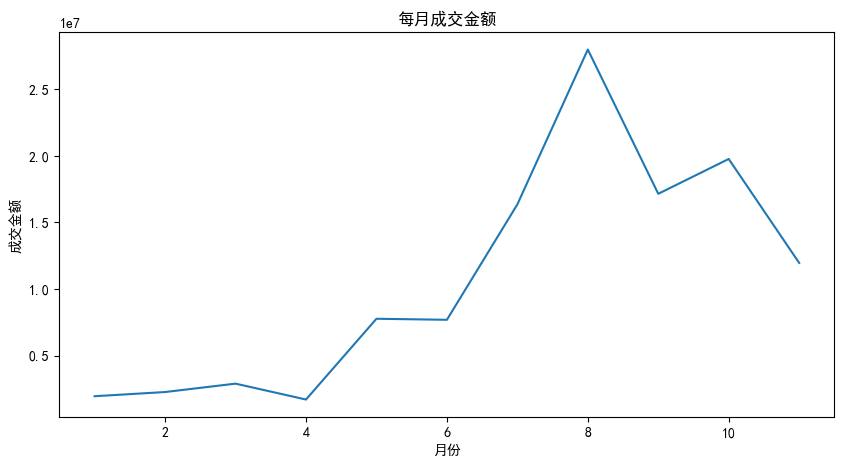

In [13]:
store_plot(data=df[df['price']>0].groupby('Month')['price'].sum(),
           xlab='月份',
           ylab='成交金额',
           title='每月成交金额')
           

每日成交金额1‑4 月整体低位徘徊；从 4 月之后开始持续快速上涨；8 月达到全年成交最高峰；8 月之后整体回落，中间有小幅反弹。。同时有两个高峰期，一个在8月，一个在10月。推测是暑假和十一引起成交金额上升。8 月是黄金旺季，需要提前备货、增加客服、保障库存，抓住最大销售窗口。

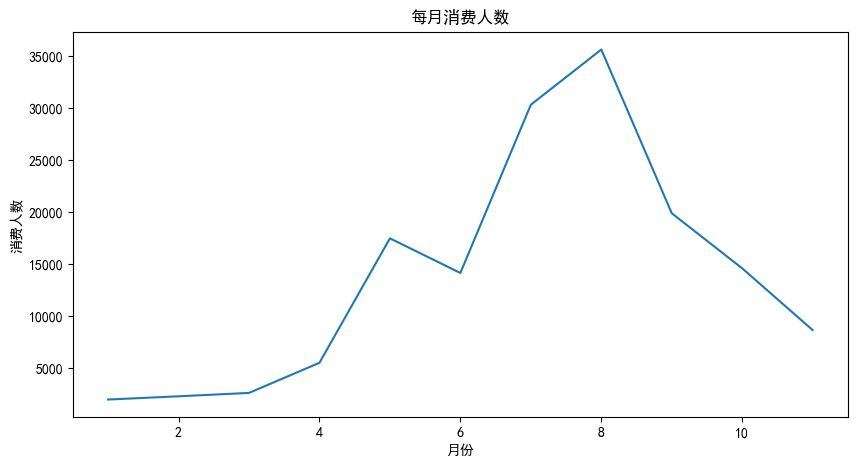

In [14]:
store_plot(data=df[df['price']>0].groupby('Month')['user_id'].nunique(),
          xlab='月份',
          ylab='消费人数',
          title='每月消费人数')


每月消费人数1月到8月呈上升趋势，8到11月呈现下降趋势。有两个高峰期，第一在5月份，第二个高峰期在6月到9月份，推测，可能是五一小长假、暑假和开学季引起了消费人数的上升。

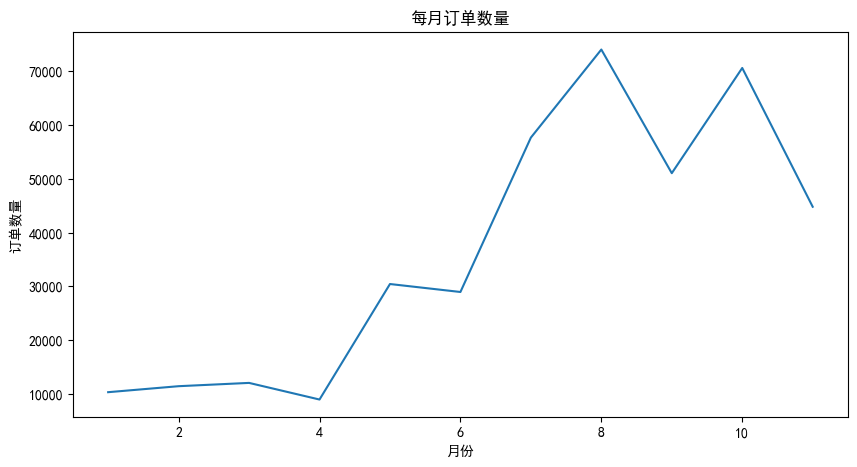

In [15]:
store_plot(data=df[df['price']>0].groupby('Month')['order_id'].nunique(),
          xlab='月份',
          ylab='订单数量',
          title='每月订单数量')


订单数量有三个小高峰，分别在5月，8月，10月，可能与五一小长假，开学季，十一小长假有关。

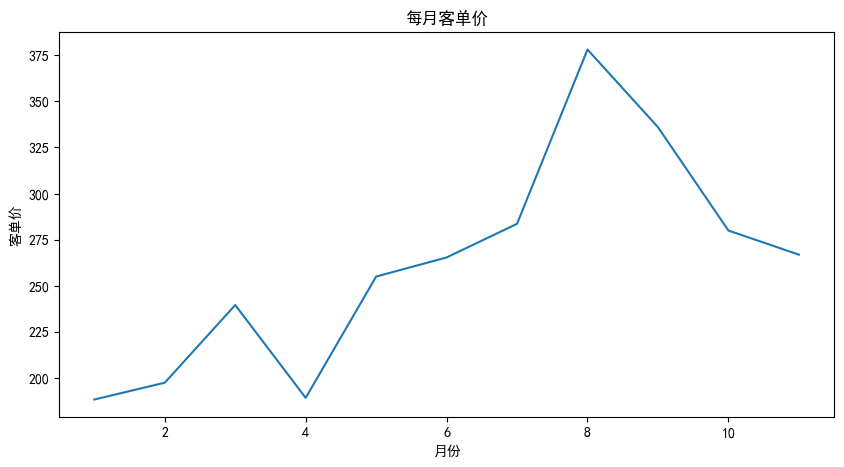

In [16]:
store_plot(data=df[df['price']>0].groupby('Month')['price'].sum()/df[df['price']>0].groupby('Month')['order_id'].nunique(),
          xlab='月份',
          ylab='客单价',
          title='每月客单价')

客单价有2个小高峰，分布在3月和8月。8月份的客单价最高，说明8月份的需求量最高，客单价、订单数量达到顶峰，每年八月份是店铺全年营收的关键期，店铺要提前准备，保证货源供应，满足客户需求量。

1、月订单数量、月消费人数、月成交金额、月客单价趋势相似，在五月份有个小高峰，在八月份是最高峰，销售情况最好的月份集中在7-9月份。店铺可以在1-4月份减少营业人员，5-11月增加营业人员，应对销售高峰期。
2、店铺销售高峰估计和五一小长假、暑假、开学季、十一小长假有关，店铺应该在这几个关键的节点，提前布局，打造竞品，加大库存量，保证货源充足。


Text(0.5, 1.0, '不同省份用户数量')

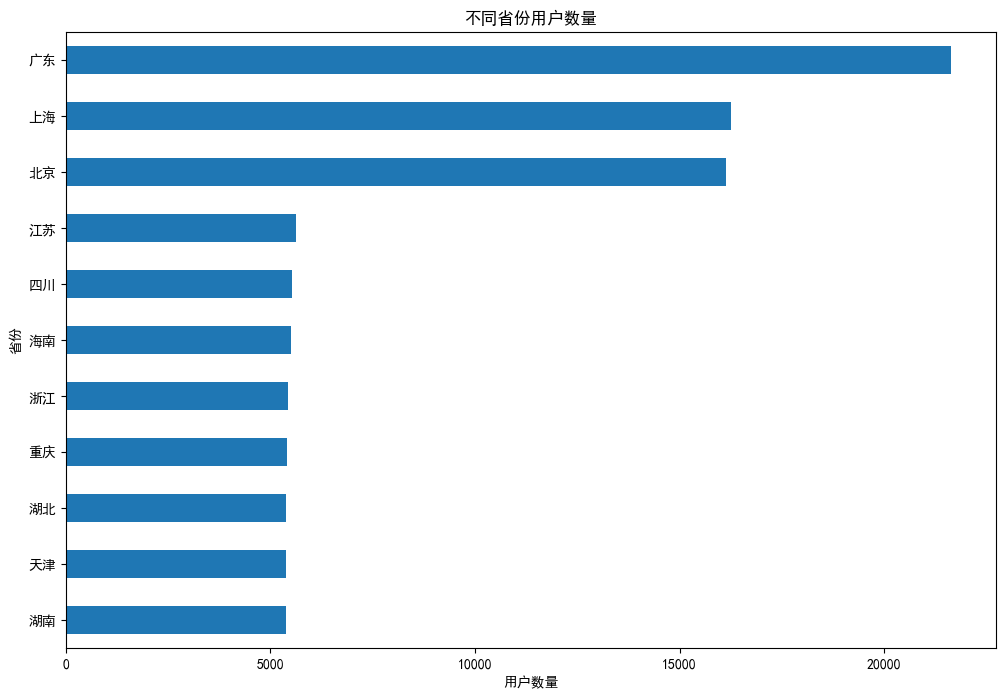

In [17]:
plt.figure(figsize=(12,8))
df[df['price']>0].groupby('local')['user_id'].nunique().sort_values(ascending=True).plot.barh()
plt.xlabel('用户数量')
plt.ylabel('省份')
plt.title('不同省份用户数量')

Text(0.5, 1.0, '不同省份订单数量')

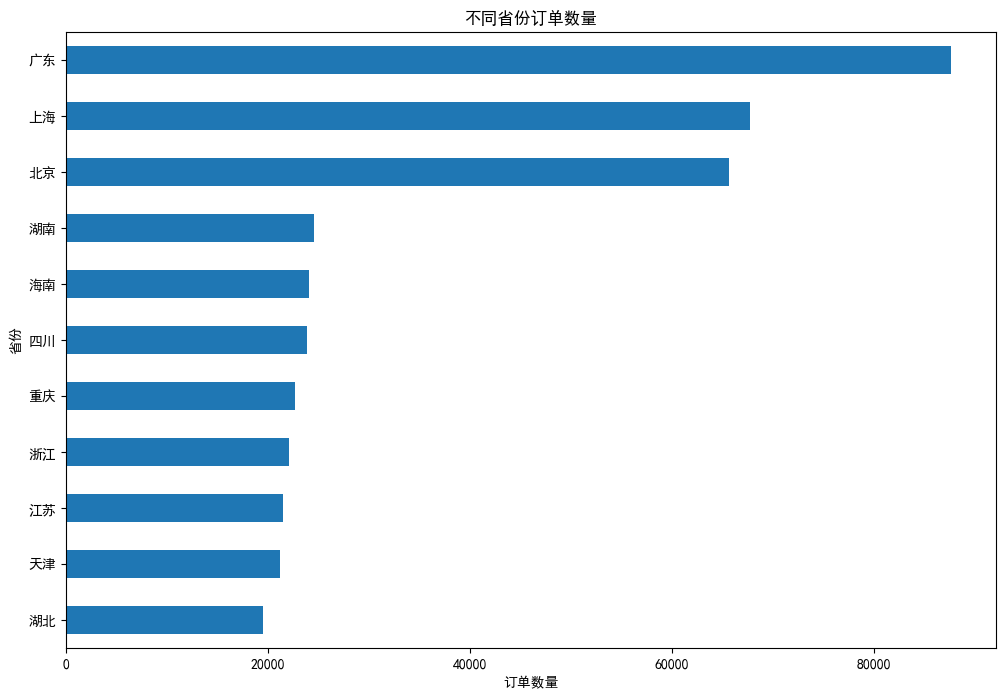

In [18]:
plt.figure(figsize=(12,8))
df[df['price']>0].groupby('local')['order_id'].nunique().sort_values(ascending=True).plot.barh()
plt.xlabel('订单数量')
plt.ylabel('省份')
plt.title('不同省份订单数量')

Text(0.5, 1.0, '不同省份成交金额')

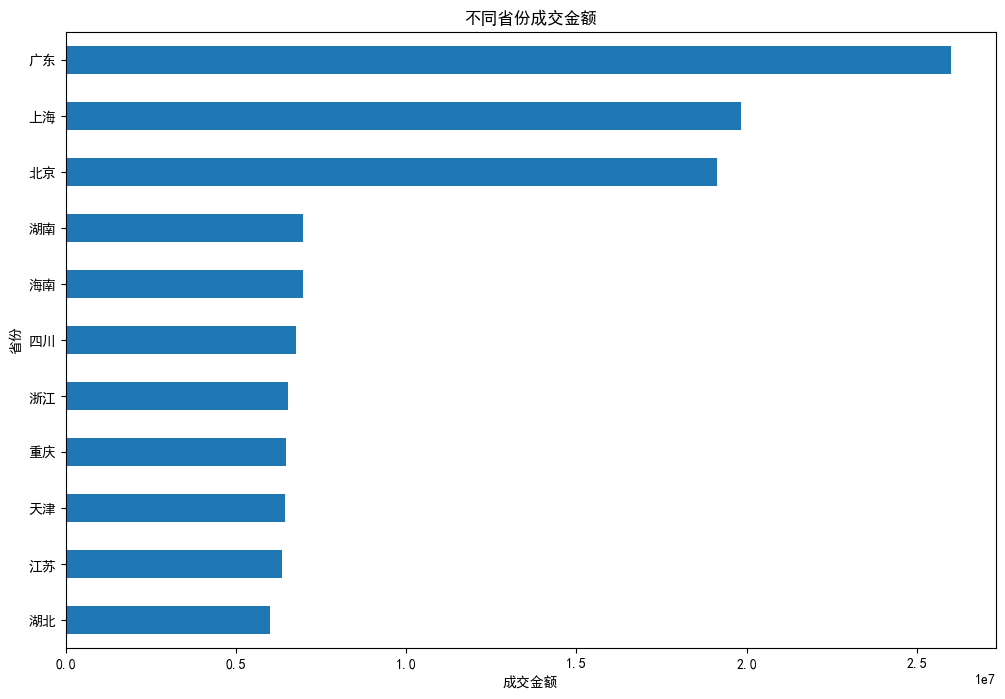

In [19]:
plt.figure(figsize=(12,8))
df[df['price']>0].groupby('local')['price'].sum().sort_values(ascending=True).plot.barh()
plt.xlabel('成交金额')
plt.ylabel('省份')
plt.title('不同省份成交金额')

1、北上广的用户数量、订单数量、成交金额都稳居前三。
2、湖南的客户数量最低，但是订单数，客单价仅次于北上广，湖南客户的潜力巨大，需要加大宣传，增加客户数量。

Text(0.5, 1.0, '订单数随星期变化')

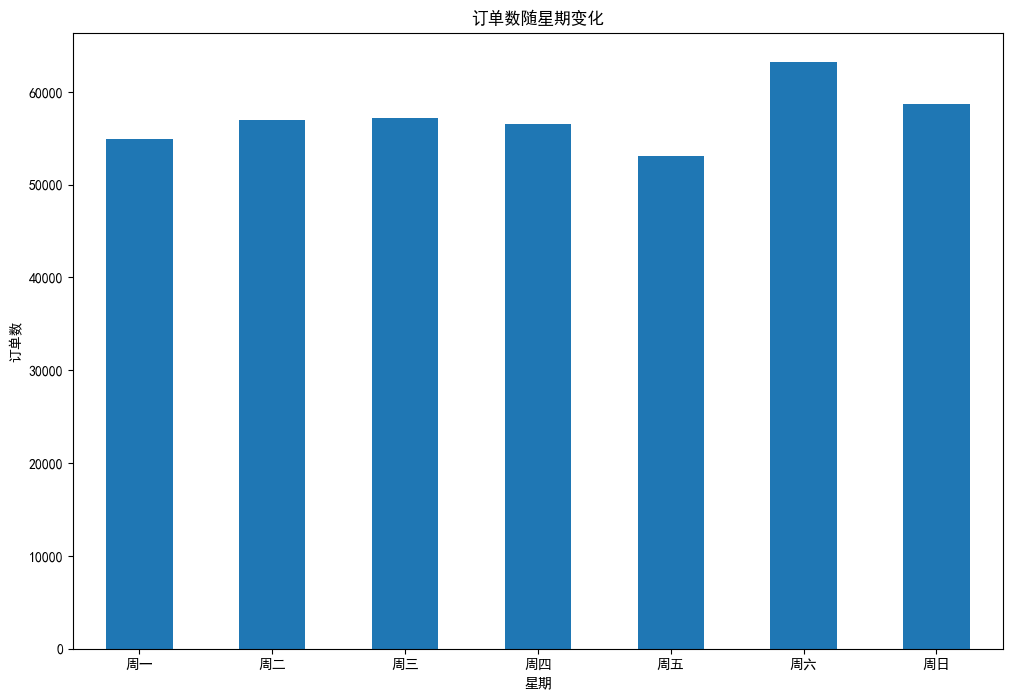

In [20]:
plt.figure(figsize=(12,8))
df[df['price']>0].groupby('Day_Of_Week')['order_id'].nunique().plot.bar()
plt.xticks(range(7),['周一','周二','周三','周四','周五','周六','周日'],rotation=0)
plt.xlabel('星期')
plt.ylabel('订单数')
plt.title('订单数随星期变化')

周一到周五订单数维持稳定，周六订单数最高，周日次之

Text(0.5, 1.0, '订单数随小时变化')

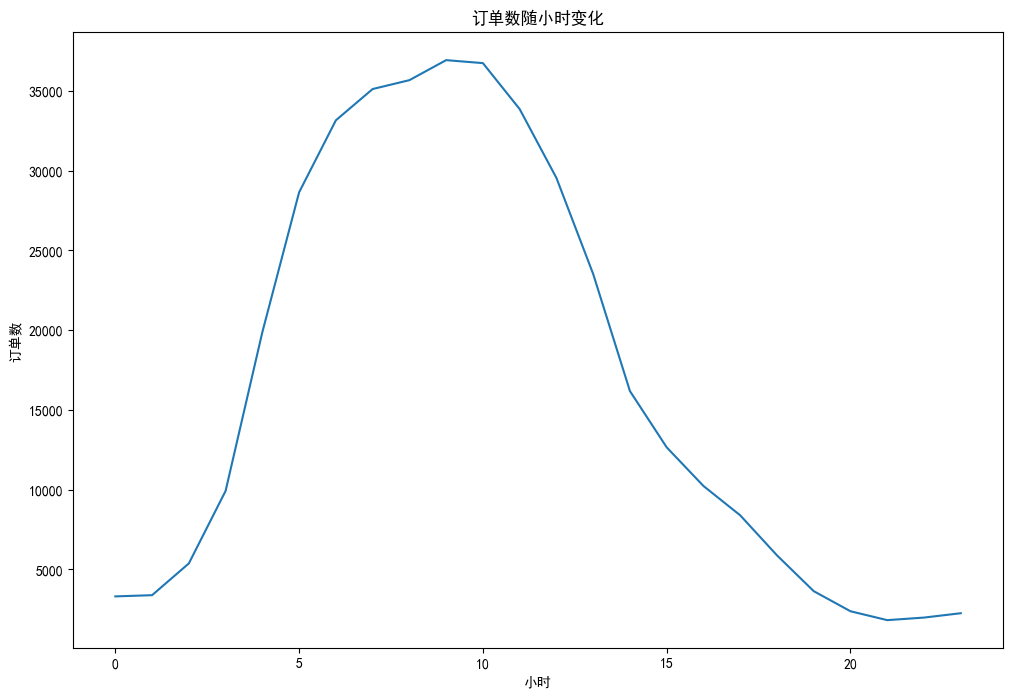

In [21]:
plt.figure(figsize=(12,8))
df[df['price']>0].groupby('Hour')['order_id'].nunique().plot()
plt.xlabel('小时')
plt.ylabel('订单数')
plt.title('订单数随小时变化')

订单集中在早晨和中午，8点到13点是消费高峰期，这段时间要注意维持好网站的稳定性。

In [22]:
df[df['price']==0].count()

Unnamed: 0       39
event_time       39
order_id         39
product_id       39
category_id      39
category_code    39
brand            39
price            39
user_id          39
age              39
sex              39
local            39
Month            39
Day              39
Day_Of_Week      39
Hour             39
dtype: int64

一共有564169条订单，未完成支付的订单只有39单，对比完成支付订单可忽略不计，因此不做未完成订单数、订单金额的统计。

In [23]:
df[df['price']>0].groupby('user_id').agg({'order_id':'nunique','price':'sum'}).describe()

,order_id,price
count,93818.000000,93818.000000
mean,4.269074,1252.415276
std,18.191671,4205.922011
min,1.000000,0.020000
25%,1.000000,145.680000
50%,2.000000,460.580000
75%,3.000000,1152.570000
max,666.000000,165439.030000


1、超过一半的用户消费了两次，甚至有用户消费了666次，估计是批发商。
2、客户平均消费金额是1252.4，标准差是4205.9，用户平均消费金额大于75分位数，存在高额消费用户。

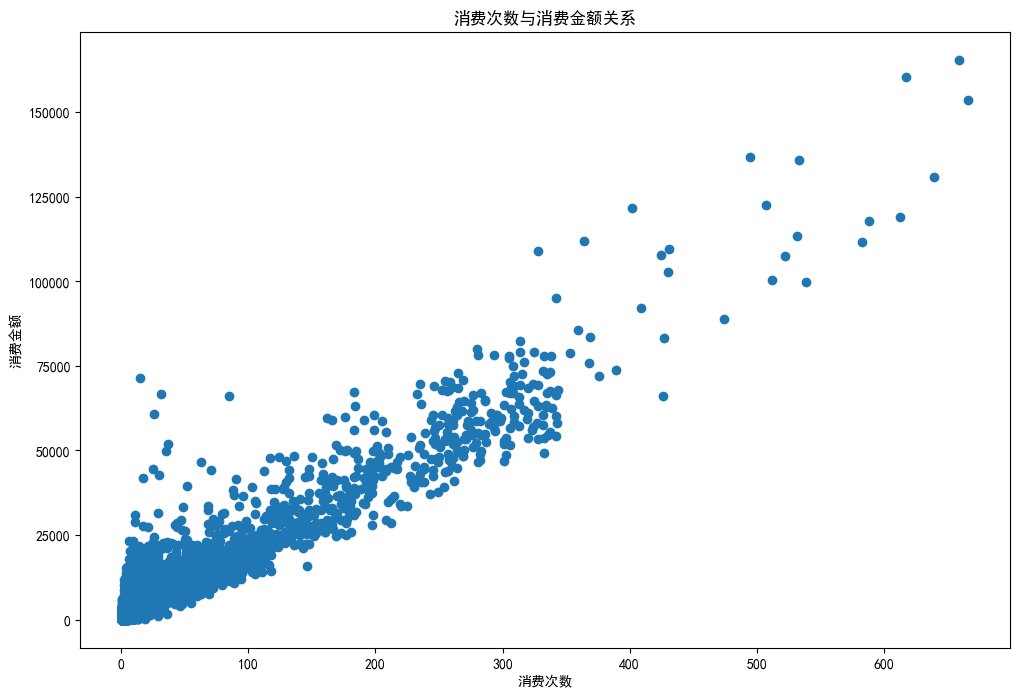

In [24]:
plt.figure(figsize=(12,8))
plt.scatter(x=df[df['price']>0].groupby('user_id')['order_id'].nunique(),
            y=df[df['price']>0].groupby('user_id')['price'].sum())
plt.xlabel('消费次数')
plt.ylabel('消费金额')
plt.title('消费次数与消费金额关系')
plt.savefig('消费次数与消费金额关系.jpeg')

消费次数和消费金额存在较强的相关性，用户消费次数越大，消费金额越大，可以引导用户多次消费。
大部分用户集中在低下单、低消费的区间，同时存在一部分高频高消费用户，体现明显的长尾效应。
相同下单次数下，不同用户总消费金额差异较大，反映用户的单次客单价存在区别。说明：下单次数只是影响消费的其中一个因素.
平台运营角度：维护老用户，提升用户复购（增加下单次数），能够有效拉动整体销售额；
但是同样下单次数，消费差距大，也可以针对用户做商品推荐，提升客单价。

In [48]:
purchase_time = df[df['price']>0].groupby('user_id').apply(
    lambda x: x.sort_values('event_time')['event_time'].diff(),include_groups=False
).dt.days
purchase_time.describe()

count    470312.000000
mean         12.284009
std         332.503336
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max       18529.000000
Name: event_time, dtype: float64

min=0：同一天多次下单；无负数，证明排序生效，时间顺序完全正确
中位数 = 0：超过一半的相邻订单都是当天连续下单，平台拆单、多笔小额、活动批量下单现象非常严重
75 分位数 = 1：75% 的两次下单间隔不超过 1 天（当天 / 次日），用户短期下单密度极高
均值 12.28 被极端超大间隔拉高，不能代表普通用户复购水平
max=18529 天（约 50 年）：明显脏时间数据，无业务意义，会严重干扰均值、标准差

In [26]:
purchase_time[purchase_time>0].describe()

count    124267.000000
mean         46.491160
std         645.632714
min           1.000000
25%           3.000000
50%          10.000000
75%          30.000000
max       18529.000000
Name: event_time, dtype: float64

删掉所有 0 天同日订单，只统计两次下单不在同一天的真实复购行为
样本只剩 12 万多：说明 47 万条间隔里，绝大部分都是同一天内重复下单，不算跨日复购
min=1：最短隔 1 天下单
均值 46.49 依然被几十年的极端脏数据拉高，参考价值有限

中位数 = 10 天：对于真正隔天才回来复购的用户，一半人 10 天内会再次下单
75% 分位数 30 天：四分之三跨日复购用户会在 30 天内二次消费
可以在第9，第29天两个时间点对用户进行推送和提醒

Text(0.5, 1.0, '用户分层')

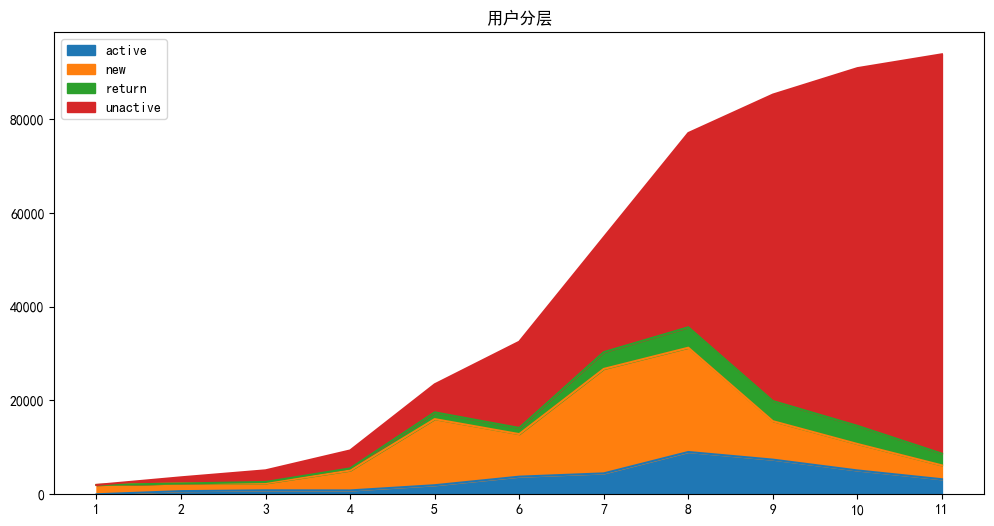

In [27]:
pivoted_amount=df[df['price']>0].pivot_table(index='user_id',
                                                columns='Month',
                                                values='price',
                                                aggfunc='mean').fillna(0)
columns_month=df['Month'].sort_values().astype('str').unique()
pivoted_amount.columns=columns_month
pivoted_purchase = (pivoted_amount > 0).astype(int)
#用户分层
def active_status(data,columns_month):
    status=[]
    for i in range(11):
        if data.iloc[i]==0:
            if len(status)>0:
                if status[i-1]=='unreg':
                    status.append('unreg')
                else:
                    status.append('unactive')
            else:
                status.append('unreg')
        else:
            if len(status)==0:
                status.append('new')
            else:
                if status[i-1]=='unactive':
                    status.append('return')
                elif status[i-1]=='unreg':
                    status.append('new')
                else:
                    status.append('active')
    return pd.Series(status,index=columns_month)
pivoted_purchase_status = pivoted_purchase.apply(lambda x:active_status(x,columns_month),axis=1)
purchase_status_counts= pivoted_purchase_status.replace('unreg',np.nan).apply(lambda x:x.value_counts())
purchase_status_counts.fillna(0).T.plot.area(figsize=(12,6))
plt.xticks(range(11),columns_month)
plt.title('用户分层')




1.新用户：1‑8 月持续增长，8 月达到新用户峰值，8‑11 月逐月回落。上半年持续获客，年中 8 月拉新效果最强，进入 9‑11 月新增用户明显收缩。
2.活跃用户：整体基数一直很低，同样8 月到达最高点（约 9000），之后逐月下降。哪怕是拉新最好的 8 月，真正保持活跃的用户规模依旧不大。
3.回流用户：走势紧跟新用户，1‑8 月上升，8 月峰值，9‑11 月持续下滑。回流用户数量低于同期新用户，但高于活跃用户；新用户涌入的时候，才有较多老用户回流；后期拉新减弱，回流也跟着变少。
4.不活跃用户：4 月之后开始快速扩张，4‑11 月持续大幅上涨，没有回落。到 11 月，不活跃用户成为占绝对大头的用户群体。
8 月是业务关键拐点：新用户、活跃、回流全部在 8 月见顶，之后全部下降；但不活跃用户还在不断变多。
针对 5‑8 月涌入的大批新用户，优化新用户留存路径，减少直接变为不活跃；
提升活跃转化，不要只追求拉新数量；
9‑11 月回流率走低，需要优化老用户召回策略，激活存量不活跃用户。

Text(0.5, 1.0, '回流率')

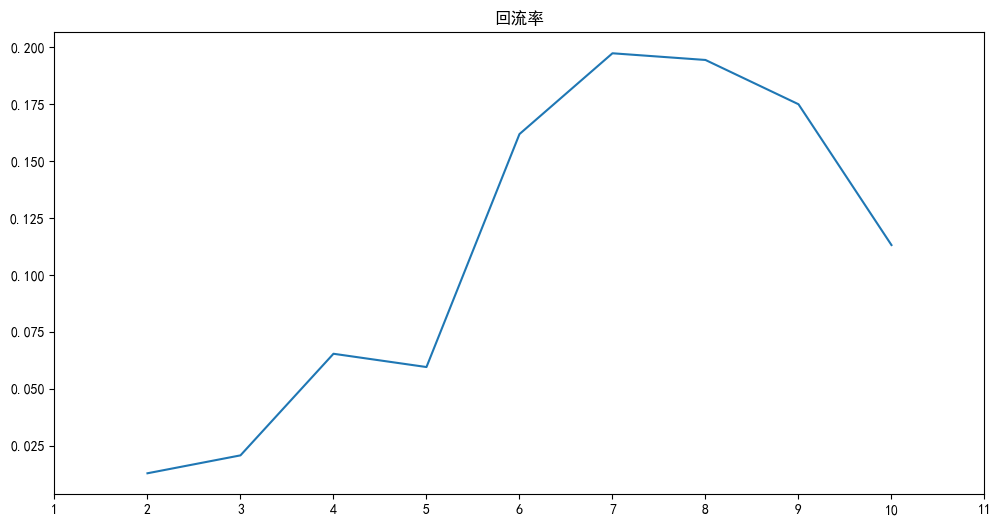

In [28]:
# 计算回流率
return_rate = purchase_status_counts.apply(lambda x:x/x.sum(),axis=1)
return_rate.loc['return'].plot(figsize=(12,6))
plt.xticks(range(1,12),columns_month)
plt.title('回流率')

回流用户从2月到7月呈增加趋势，四月有所回落，五月开始保持快速增长，7月初到达顶峰，7月开始回落但依然保持较高的回流率。

Text(0.5, 1.0, '复购率')

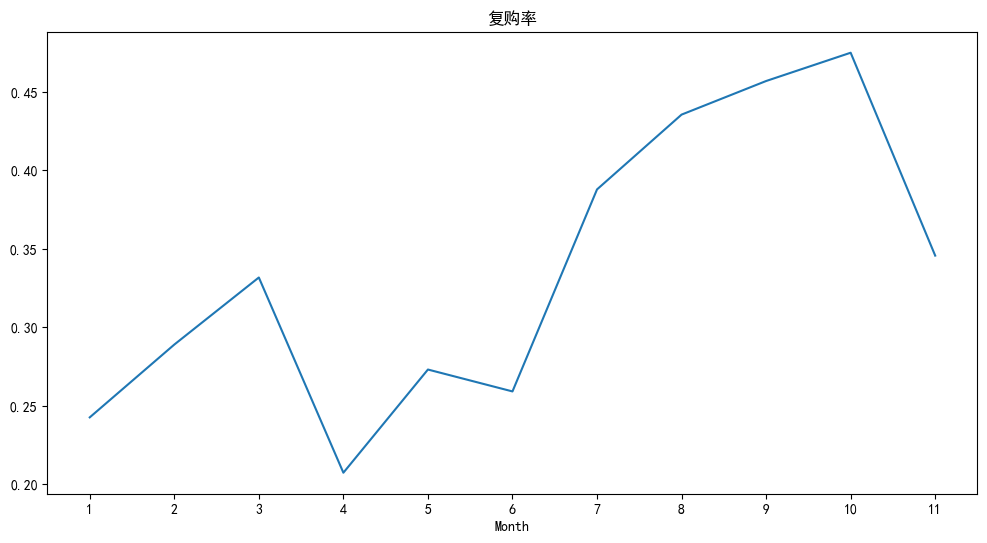

In [29]:
#计算复购率
pivoted_counts = df[df['price']>0].pivot_table(index='user_id',
                                              columns='Month',
                                             values='order_id',
                                             aggfunc='nunique').fillna(0)
columns_month = df['Month'].sort_values().astype('str').unique()
pivoted_counts_transf = pivoted_counts.map(lambda x: 1 if x>1 else np.nan if x==0 else 0)
(pivoted_counts_transf.sum()/pivoted_counts_transf.count()).plot(figsize=(12,6))
plt.xticks(range(1,12),columns_month)
plt.title('复购率')


复购率3月、5月、10月有三个小高峰，其中10月份复购率最高，从6月开始到10月复购率一直保持增长。一直保持较高的复购率。其中三个小高峰估计和清明小长假、五一小长假、十一小长假有关。

Text(0.5, 1.0, '回购率')

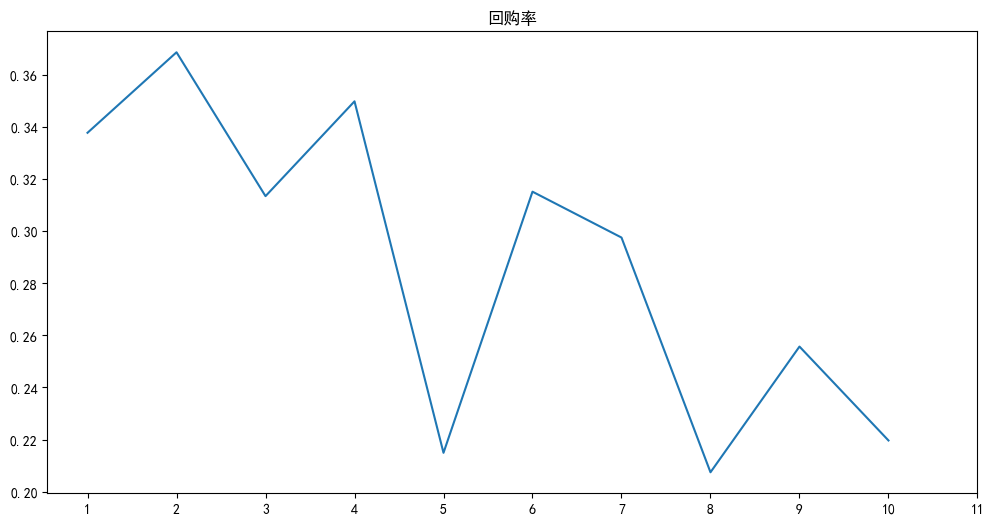

In [30]:
def purchase_return(data):
    status = []
    for i in range(10):
        if data.iloc[i]==1:
            if data.iloc[i+1]==1:
                status.append(1)
            else: 
                status.append(0)
        else :
            status.append(np.nan)
    status.append(np.nan)
    return pd.Series(status,index=columns_month)
pivoted_purchase_return = pivoted_purchase.apply(purchase_return,axis=1)
(pivoted_purchase_return.sum()/pivoted_purchase_return.count()).plot(figsize=(12,6))
plt.xticks(range(11),columns_month)
plt.title('回购率')

回购率从1月到11月总体呈现下降趋势。其中3月、5月、8月、10月下降最厉害，估计和清明小长假、五一小长假、暑假、十一小长假有关。

3月、5月、10月这三个节点在两张图中呈现出截然相反的走势，揭示了用户群体中存在的“流量质量”与“用户结构”的深层矛盾。
简单来说：复购率看的是“老客稳不稳”，回购率看的是“新客接不接得上”。
3月：高复购、低回流 —— “老客死忠，新客断档”。1-2月是春节旺季，很多用户是为了过节囤货（如礼品、年货）。到了3月，这些季节性需求瞬间消失，导致2月的大批用户无法转化为3月的活跃用户。 3月通常是淡季，如果没有强有力的营销活动引入高质量新用户，仅靠老客维持，就会出现“老客还在买（复购高），但没人接力（回流低）”的局面。
5月：低复购、低回流 —— “全面崩盘，流量垃圾”：淡季中的淡季，既没有节日刺激，老客也处于购买疲劳期
10月：低复购、高回流 —— “爆款拉新，老客流失”：量低质新用户涌入： 10月可能有国庆大促或换季爆款。大量新用户因为活动进来买了第一次（推高了9-10月的回流数据）。
分母效应： 复购率 = 多次购买人数 / 总购买人数。因为10月涌入的大量新用户只买了一次（作为分母变大了），导致整体的复购比例被稀释下降了。
结论： 10月的繁荣是“流量驱动”的，而不是“品牌驱动”的。热闹是热闹，但没留住人。


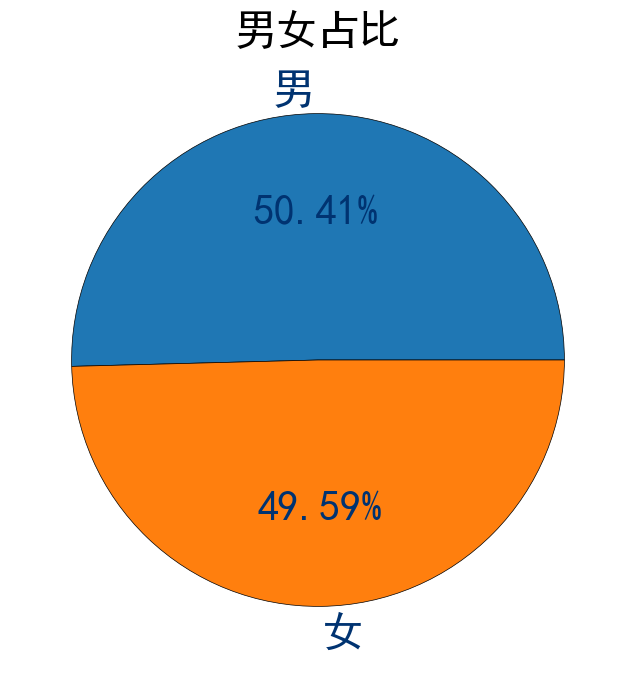

In [31]:
df=df[df['price']>0]
df_sex=df['sex'].value_counts()
plt.figure(figsize=(8,8))
plt.pie(df_sex.values,labels=df_sex.index,autopct='%.2f%%',wedgeprops={'linewidth':0.5,'edgecolor':'black'},textprops={'fontsize':30,'color':'#003371'})
plt.title('男女占比',size=30)
plt.show()

In [32]:
df['age'].describe()

count    564130.000000
mean         33.184326
std          10.122218
min          16.000000
25%          24.000000
50%          33.000000
75%          42.000000
max          50.000000
Name: age, dtype: float64

In [33]:
bins=[10,20,30,40,50]
df['age_box']=pd.cut(df['age'],bins,labels=['10-20','20-30','30-40','40-50'])
age_box=df['age_box'].value_counts()
age_box

age_box
40-50    169567
20-30    159756
30-40    156550
10-20     78257
Name: count, dtype: int64

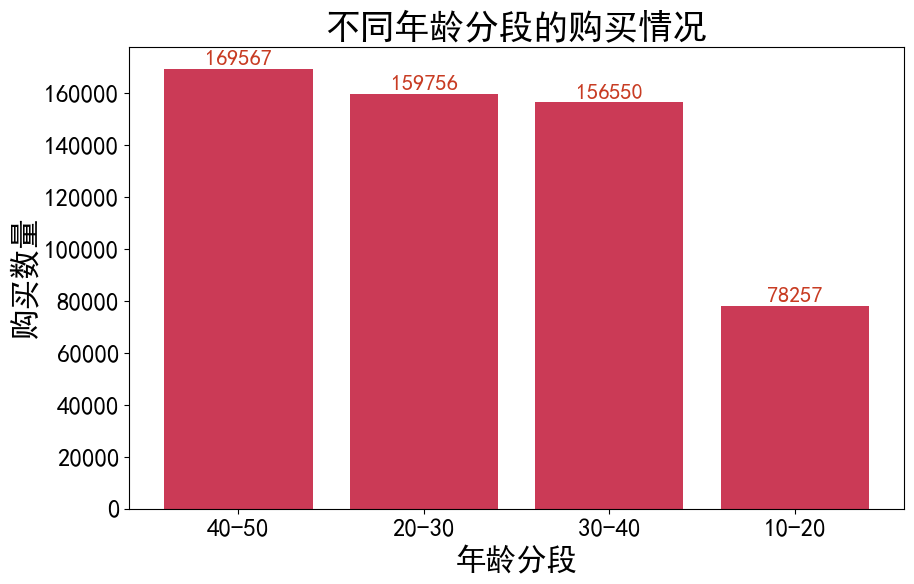

In [34]:
plt.figure(figsize=(10,6))
plt.bar(age_box.index,age_box.values,color='#cb3a56')
plt.ylabel('购买数量',size=22)
plt.xlabel('年龄分段',size=22)
plt.xticks(size=18)
plt.yticks(size=18)
for x,y in zip(age_box.index,age_box.values):
    plt.text(x,y+500,"%d"%y,ha='center',va='bottom',size=16,color='#c83c23')
plt.title('不同年龄分段的购买情况',size=25)
plt.show()

40‑50 岁群体购买数量最高，是核心购买主力；
20‑30 岁、30‑40 岁购买规模接近，同样是重要消费群体；
而 10‑20 岁年龄段购买数量远低于其他分组。
造成该差异的主要原因是各年龄段购买力存在区别，该结果体现了本平台的消费用户画像。

In [35]:
df.groupby('age_box',observed=False)['sex'].value_counts()

age_box  sex
10-20    女      39858
         男      38399
20-30    女      80159
         男      79597
30-40    男      81535
         女      75015
40-50    男      84863
         女      84704
Name: count, dtype: int64

In [36]:
df_brand=df['brand'].value_counts().head(12)
df_brand

brand
samsung    96239
apple      36084
missing    27215
ava        26123
tefal      17956
lg         16696
xiaomi     14869
philips    12151
polaris    10730
huawei     10722
bosch      10206
asus        9118
Name: count, dtype: int64

In [37]:
df[df['brand'].isin(df_brand.index)].groupby('sex').describe()['price']

,count,mean,min,25%,50%,75%,max,std
sex,,,,,,,,
女,143151.0,287.819252,0.02,46.27,173.59,393.5,9606.48,346.133224
男,144958.0,289.186898,0.02,46.27,173.59,393.5,18328.68,356.553973


男性和女性对价格的在价格的75分位及以下消费情况一基本致，但是男性对高价格的产品的消费能力远超女性。

In [38]:
df[df['brand'].isin(df_brand.index)].groupby('age_box',observed=False).describe()['price']

,count,mean,min,25%,50%,75%,max,std
age_box,,,,,,,,
10-20,40064.0,288.570671,0.02,48.59,173.59,393.5000,7407.38,345.751456
20-30,81552.0,291.932090,0.02,46.27,173.59,396.1575,9606.48,352.620109
30-40,80530.0,289.774748,0.02,46.27,173.59,393.5000,11574.05,352.117137
40-50,85963.0,284.041581,0.02,46.27,162.01,381.9200,18328.68,352.188401


不同年龄段人群在购买价格的75%分位上基本一致，但是34-40岁，40-50岁的人群对高价格产品的购买力更强。

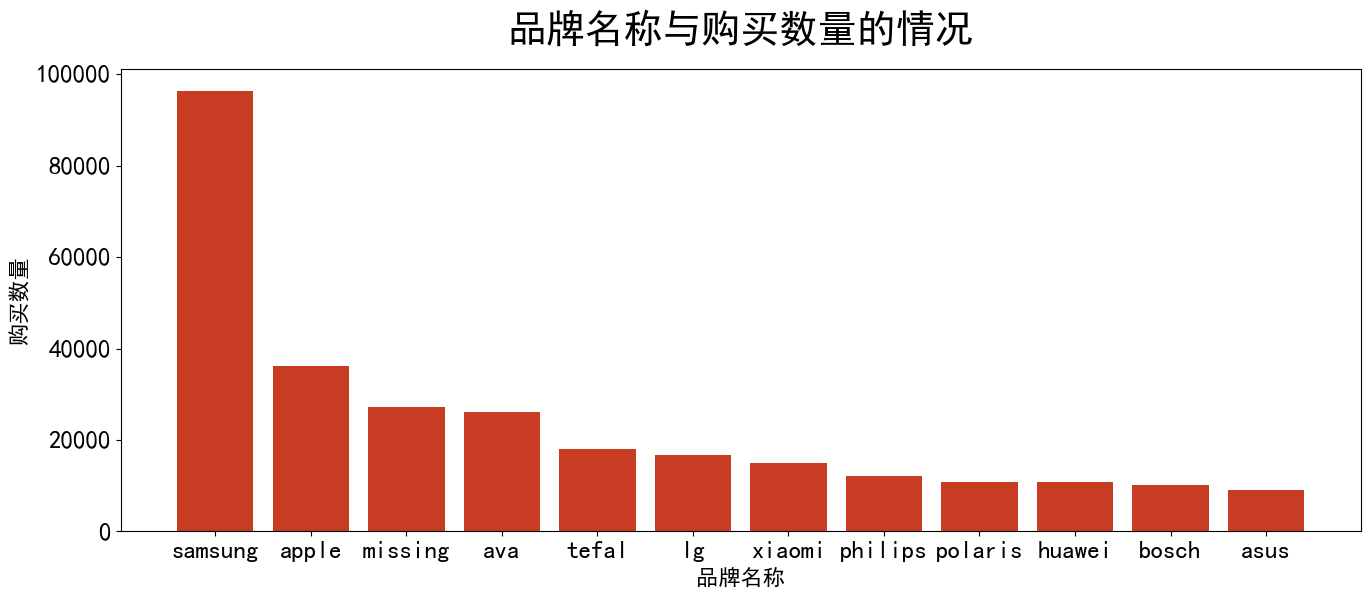

In [39]:
df_brand = df['brand'].value_counts().head(12)
plt.figure(figsize=(16,6))
plt.bar(df_brand.index,df_brand.values,color='#c83c23')
plt.xticks(size=18)
plt.yticks(size=18)
plt.xlabel("品牌名称",size=16)
plt.ylabel("购买数量",size=16)
plt.title('品牌名称与购买数量的情况',size=28,pad=20)
plt.show()

大家最喜欢的品牌是samsung、apple、ava。由于部分手机品牌信息缺失用missing代替，missing可能包含很多品牌。所以最喜欢的品牌忽略missing.

In [40]:
df['price'].quantile([0,0.25,0.5,0.75,1]).tolist()

[0.02, 23.13, 87.94, 277.75, 18328.68]

In [41]:
df['price_box']=pd.cut(df['price'],
                       df['price'].quantile([0,0.25,0.5,0.75,1]).tolist(),
                       labels=['0.02-23.13','23.13-87.94','87.94-277.75','277.75-18328.68'])
df['price_box'].value_counts()

price_box
0.02-23.13         147549
87.94-277.75       142358
277.75-18328.68    139399
23.13-87.94        134173
Name: count, dtype: int64

把年龄分为四层，每层的购买人数大致相当

In [42]:
df[df['brand'].isin(df_brand.index)].groupby('brand').describe()['price']

,count,mean,min,25%,50%,75%,max,std
brand,,,,,,,,
apple,36084.0,720.514260,2.29,324.05,740.72,925.67,6018.50,475.576531
asus,9118.0,556.995058,13.87,305.53,509.24,763.87,4629.61,348.708996
ava,26123.0,75.383470,0.02,11.55,41.64,138.87,1273.13,99.421969
bosch,10206.0,327.873193,4.84,133.54,300.90,462.94,1527.75,246.052661
huawei,10722.0,207.689580,3.22,127.29,162.01,254.61,1157.38,156.018227
lg,16696.0,468.235000,16.18,300.90,407.38,543.96,11574.05,332.623621
missing,27215.0,85.832448,0.02,4.14,16.18,55.53,18328.68,245.522559
philips,12151.0,83.750141,1.60,37.01,50.90,87.94,1157.38,102.258354
polaris,10730.0,40.508892,4.61,23.13,37.01,47.20,313.63,25.025027


In [43]:
df.groupby('order_id')[['price']].sum().describe()

,price
count,400516.000000
mean,293.369295
std,397.071623
min,0.020000
25%,41.640000
50%,148.340000
75%,393.500000
max,18699.030000


75% 的成交商品价格不超过 393.5 元，反映大部分购买行为偏向低价产品；仅有 25% 的成交记录价格高于 393.5 元，这部分包含大量高价商品。